<a href="https://colab.research.google.com/github/kholoud400/ML-NN-CNN-projects/blob/main/AirQualityProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install catboost lightgbm xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.1 MB/s eta 0:00:00


In [ ]:
!pip install lightgbm
!pip install xgboost

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split


In [ ]:
df=pd.read_csv('/content/city_day.csv')

In [ ]:
df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB


In [ ]:
df.nunique()

,0
City,26
Date,2009
PM2.5,11716
PM10,12571
NO,5776
NO2,7404
NOx,8156
NH3,5922
CO,1779
SO2,4761


In [ ]:
df.shape

(29531, 16)

In [ ]:
df.isnull().sum().sort_values()

,0
City,0
Date,0
CO,2059
NO,3582
NO2,3585
SO2,3854
O3,4022
NOx,4185
PM2.5,4598
AQI_Bucket,4681


In [ ]:
df.dropna(subset=['AQI'], inplace=True)

In [ ]:
df.isnull().sum().sort_values()

,0
City,0
Date,0
AQI_Bucket,0
AQI,0
NO,387
NO2,391
CO,445
SO2,605
PM2.5,678
O3,807


In [ ]:
df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
28,Ahmedabad,2015-01-29,83.13,NaN,6.93,28.71,33.72,NaN,6.93,49.52,59.76,0.02,0.00,3.14,209.0,Poor
29,Ahmedabad,2015-01-30,79.84,NaN,13.85,28.68,41.08,NaN,13.85,48.49,97.07,0.04,0.00,4.81,328.0,Very Poor
30,Ahmedabad,2015-01-31,94.52,NaN,24.39,32.66,52.61,NaN,24.39,67.39,111.33,0.24,0.01,7.67,514.0,Severe
31,Ahmedabad,2015-02-01,135.99,NaN,43.48,42.08,84.57,NaN,43.48,75.23,102.70,0.40,0.04,25.87,782.0,Severe
32,Ahmedabad,2015-02-02,178.33,NaN,54.56,35.31,72.80,NaN,54.56,55.04,107.38,0.46,0.06,35.61,914.0,Severe


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
x=df.drop(['AQI','AQI_Bucket'],axis=1)
y=df['AQI']

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,shuffle=True,random_state=42)

In [ ]:
x_train["Date"] = pd.to_datetime(x_train["Date"])

x_train["Year"] = x_train["Date"].dt.year
x_train["Month"] = x_train["Date"].dt.month

x_train.drop("Date", axis=1, inplace=True)

In [ ]:
x_test["Date"] = pd.to_datetime(x_test["Date"])

x_test["Year"] = x_test["Date"].dt.year
x_test["Month"] = x_test["Date"].dt.month

x_test.drop("Date", axis=1, inplace=True)

In [ ]:
from sklearn.impute import SimpleImputer


In [ ]:
# cat_col=x_train.select_dtypes(include='object').columns
# num_col=x_train.select_dtypes(exclude='object').columns

In [ ]:
# x_train_num = x_train[num_col]
# x_test_num = x_test[num_col]

# x_train_cat = x_train[cat_col]
# x_test_cat = x_test[cat_col]

In [ ]:
# imputer_num = SimpleImputer(strategy="median")

# x_train_num = imputer_num.fit_transform(x_train_num)
# x_test_num = imputer_num.transform(x_test_num)

In [ ]:
# imputer_cat = SimpleImputer(strategy="most_frequent")

# x_train_cat = imputer_cat.fit_transform(x_train_cat)
# x_test_cat = imputer_cat.transform(x_test_cat)

In [ ]:
# encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

# x_train_cat = encoder.fit_transform(x_train_cat)
# x_test_cat = encoder.transform(x_test_cat)

# cat_columns = encoder.get_feature_names_out(cat_col)

# x_train_cat = pd.DataFrame(x_train_cat, columns=cat_columns)
# x_test_cat = pd.DataFrame(x_test_cat, columns=cat_columns)

In [ ]:
# x_train_num = pd.DataFrame(x_train_num, columns=num_col)
# x_test_num = pd.DataFrame(x_test_num, columns=num_col)

In [ ]:
# x_train_cat = pd.DataFrame(x_train_cat)
# x_test_cat = pd.DataFrame(x_test_cat)

In [ ]:
# x_train = pd.concat([x_train_num, x_train_cat], axis=1)
# x_test = pd.concat([x_test_num, x_test_cat], axis=1)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error,mean_squared_error,root_mean_squared_error
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

In [ ]:
num_cols = x_train.select_dtypes(exclude="object").columns
cat_cols = x_train.select_dtypes(include="object").columns

In [ ]:
preprocessor = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]), cat_cols)
])

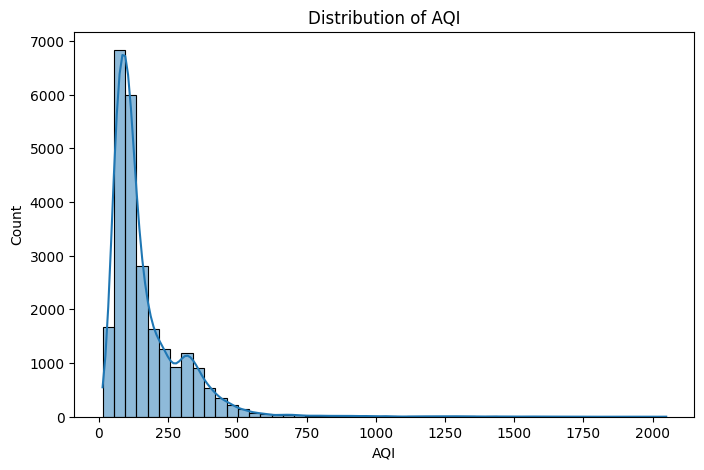

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["AQI"], bins=50, kde=True)
plt.title("Distribution of AQI")
plt.show()

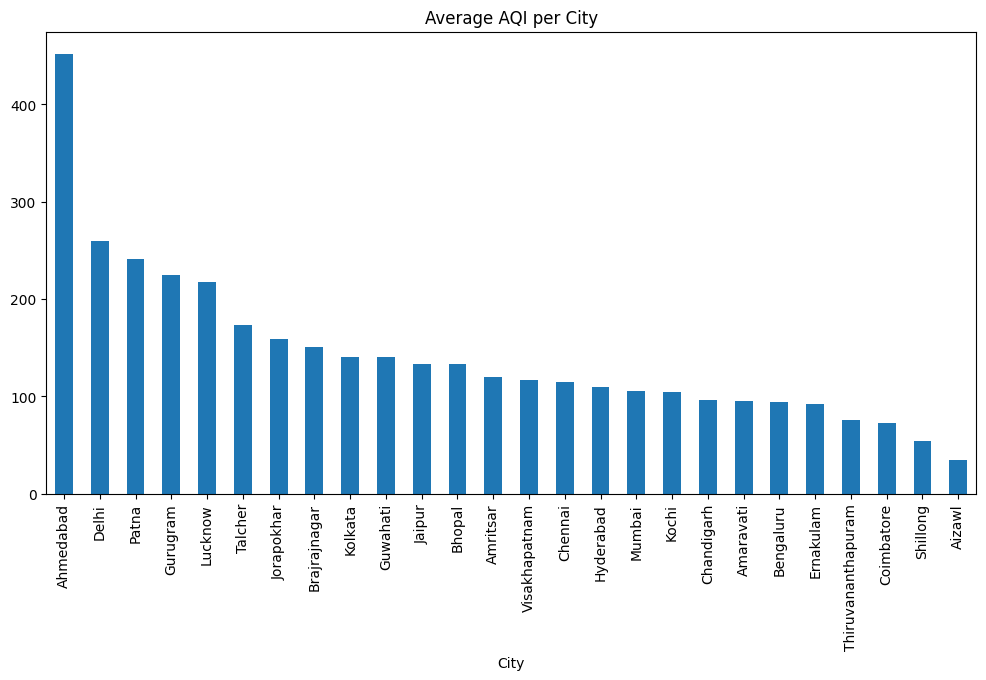

In [ ]:
plt.figure(figsize=(12,6))
city_aqi = df.groupby("City")["AQI"].mean().sort_values(ascending=False)
city_aqi.plot(kind="bar")
plt.title("Average AQI per City")
plt.show()

In [ ]:
train_df = pd.concat(
    [x_train, pd.Series(y_train, name="AQI")],
    axis=1
)

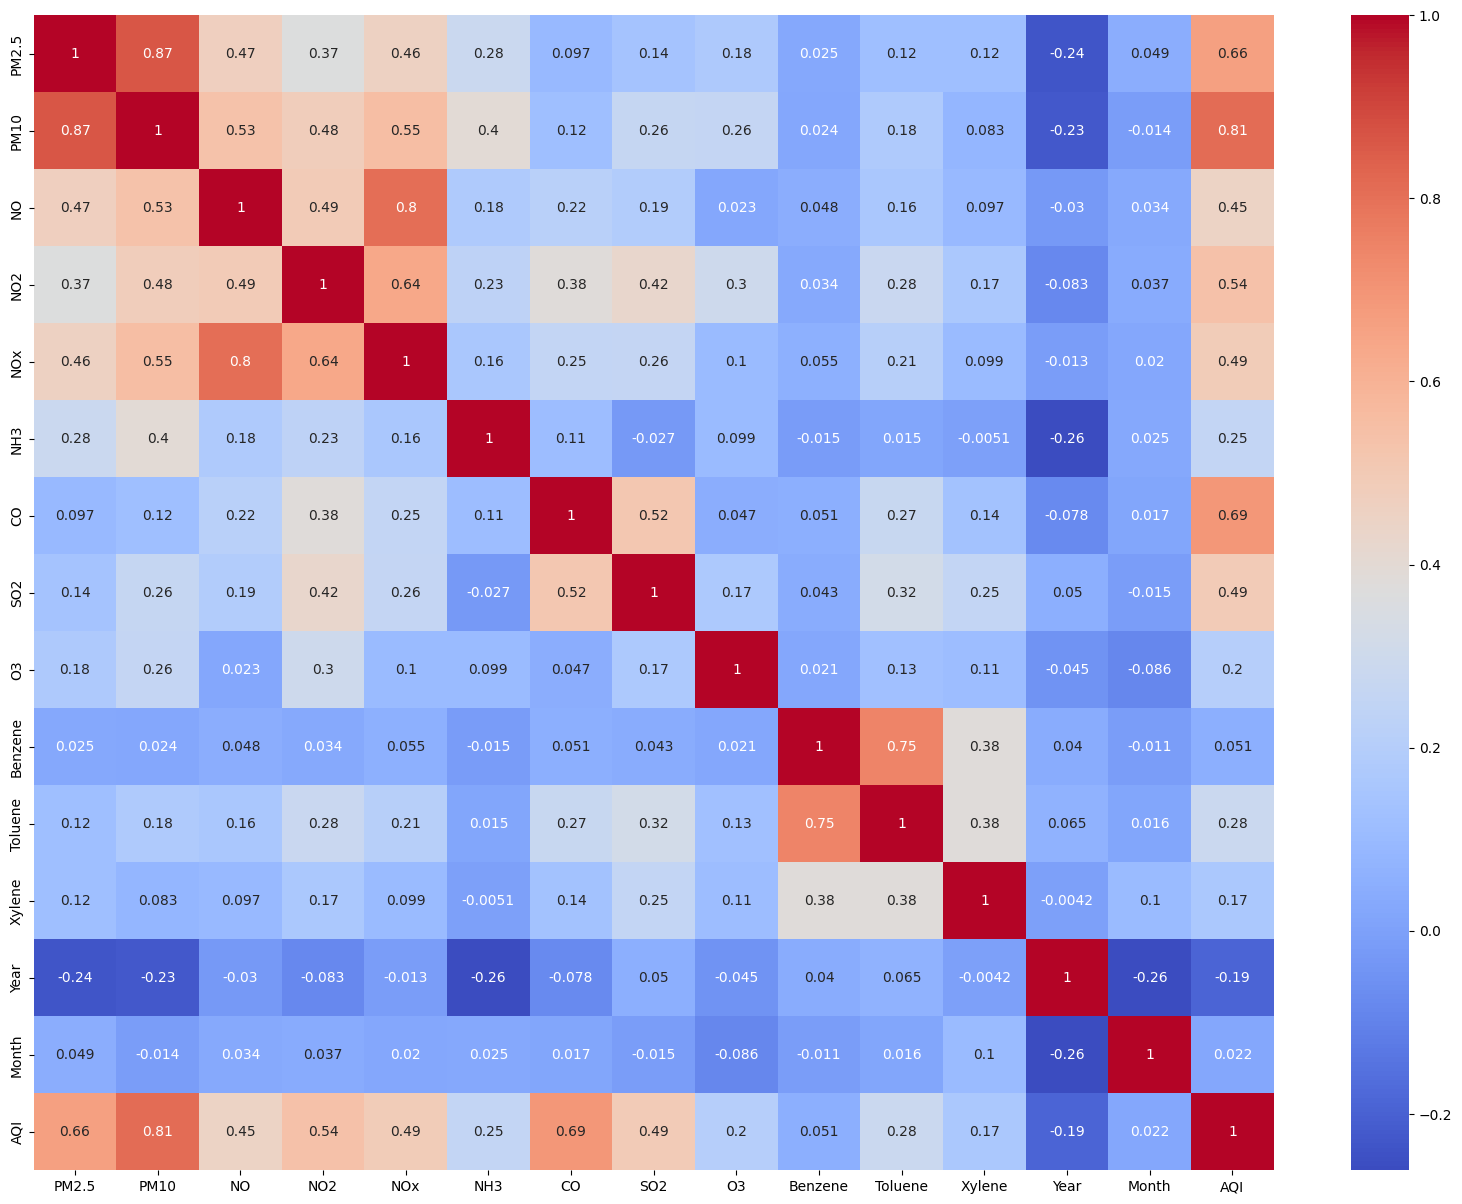

In [ ]:
plt.figure(figsize=(20, 15))
sns.heatmap(train_df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

In [ ]:
train_df = pd.concat([x_train, y_train.rename("AQI")], axis=1)

corr = train_df.corr(numeric_only=True)["AQI"].sort_values(ascending=False)

top10 = corr.drop("AQI").head(10)
print(top10)

PM10       0.808622
CO         0.693553
PM2.5      0.660435
NO2        0.539565
SO2        0.492531
NOx        0.489167
NO         0.452765
Toluene    0.282791
NH3        0.251450
O3         0.203194
Name: AQI, dtype: float64


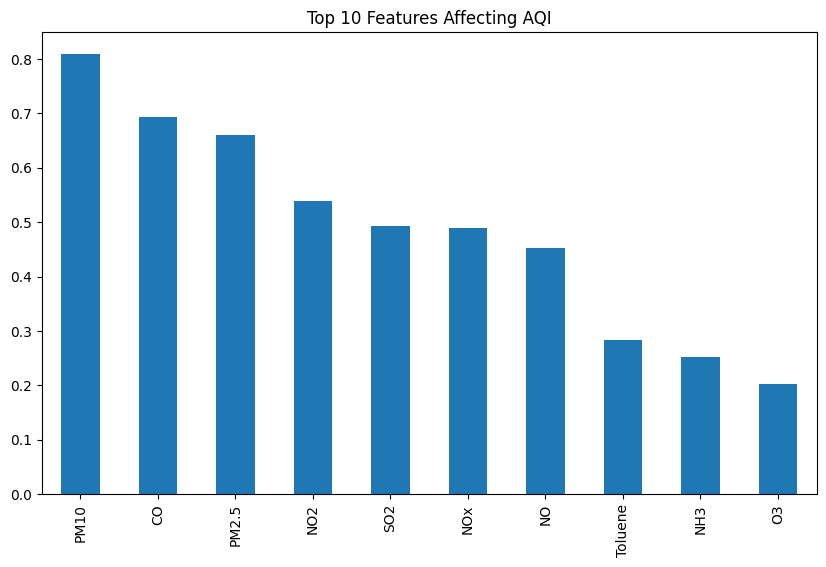

In [ ]:
plt.figure(figsize=(10,6))
top10.plot(kind="bar")
plt.title("Top 10 Features Affecting AQI")
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    BaggingRegressor,
    AdaBoostRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor
)

from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor


models = {

    # Linear Models
    "Linear Regression": LinearRegression(),

    "Lasso": Lasso(),

    "Ridge": Ridge(),


    # Distance-Based Model
    "KNN": KNeighborsRegressor(
        n_neighbors=5,
        metric='minkowski',
        p=1
    ),


    # Support Vector Machine
    "SVM": SVR(
        kernel='linear',
        C=100,
        gamma=1
    ),


    # Tree-Based Model
    "Decision Tree": DecisionTreeRegressor(
        criterion='squared_error',
        max_depth=10,
        random_state=42
    ),


    # Ensemble Models
    "Random Forest": RandomForestRegressor(
        n_estimators=50,
        criterion='squared_error',
        max_depth=10,
        random_state=42
    ),

    "ExtraTrees": ExtraTreesRegressor(
        n_estimators=100,
        random_state=42
    ),

    "Bagging": BaggingRegressor(
        estimator=DecisionTreeRegressor(
            criterion='squared_error',
            max_depth=10
        ),
        n_estimators=50,
        random_state=42
    ),


    # Boosting Models
    "AdaBoost": AdaBoostRegressor(
        n_estimators=15,
        random_state=42
    ),

    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42
    ),

    "HistGradientBoosting": HistGradientBoostingRegressor(
        max_iter=100,
        learning_rate=0.1,
        random_state=42
    ),


    # Advanced Boosting Models
    "XGBoost": XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42,
        verbosity=0
    ),

    "CatBoost": CatBoostRegressor(
        verbose=0,
        iterations=100,
        learning_rate=0.1,
        random_state=42
    ),

    "LightGBM": LGBMRegressor(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42
    )
}

In [ ]:
results = {}

for name, reg in models.items():

    model = Pipeline([
        ("preprocessor", preprocessor),
        ("regressor", reg)
    ])

    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)

    mse = mean_squared_error(y_test, y_pred)

    results[name] = {
        "R2": r2_score(y_test, y_pred),
        "MAE": mean_absolute_error(y_test, y_pred),
        "MSE": mse,
        "RMSE": np.sqrt(mse)
    }

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001093 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3132
[LightGBM] [Info] Number of data points in the train set: 19880, number of used features: 40
[LightGBM] [Info] Start training from score 166.818360


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [ ]:
results_df = pd.DataFrame(results).T
results_df.sort_values(by="R2", ascending=False)

,R2,MAE,MSE,RMSE
LightGBM,0.912123,20.951522,1609.122606,40.113870
ExtraTrees,0.908254,20.153359,1679.970785,40.987447
Bagging,0.906620,21.950652,1709.885305,41.350759
Random Forest,0.906476,21.933591,1712.524812,41.382663
HistGradientBoosting,0.904394,21.102753,1750.642322,41.840678
XGBoost,0.902042,20.867665,1793.716917,42.352295
CatBoost,0.900696,22.702329,1818.360391,42.642237
GradientBoosting,0.899049,23.126787,1848.515106,42.994361
KNN,0.886419,22.849014,2079.780958,45.604616
Decision Tree,0.863667,24.535697,2496.392230,49.963909


In [ ]:
best_model_name = results_df["R2"].idxmax()
best_model_name

'LightGBM'

In [ ]:
best_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", models[best_model_name])
])

best_model.fit(x_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002703 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3132
[LightGBM] [Info] Number of data points in the train set: 19880, number of used features: 40
[LightGBM] [Info] Start training from score 166.818360


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3',
       'Benzene', 'Toluene', 'Xylene', 'Year', 'Month'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['City'], dtype='object'))])),
                ('regressor', LGBMRegressor(random_state=42))])

In [ ]:
import joblib

joblib.dump(best_model, "aqi_best_model.pkl")

['aqi_best_model.pkl']

In [ ]:
%%writefile application.py

Writing application.py
